# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import random
import os
from tqdm import tqdm
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

2025-06-08 16:08:41.242967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749398921.446945      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749398921.508213      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load the dataset


In [2]:
# Set seed for reproducibility
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed_value)

set_seed(42)

In [3]:
# Load Data
file_path = '/kaggle/input/personal-care/amazon_reviews_us_Personal_Care_Appliances_v1_00.tsv'
df = pd.read_csv(file_path, on_bad_lines='skip', sep='\t')

# Display the shape of the dataset


In [4]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset contains 85924 rows and 15 columns.



# Display the first few rows


In [5]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,32114233,R1QX6706ZWJ1P5,B00OYRW4UE,223980852,Elite Sportz Exercise Sliders are Double Sided...,Personal_Care_Appliances,5,0,0,N,Y,Good quality. Shipped,Exactly as described. Good quality. Shipped fast,2015-08-31
1,US,18125776,R3QWMLJHIW6P37,B0000537JQ,819771537,Ezy Dose Weekly,Personal_Care_Appliances,5,0,0,N,Y,Five Stars,It is great,2015-08-31
2,US,19917519,R14Z1VR1N0Z9G6,B00HXXO332,849307176,"Pulse Oximeter, Blood Oxygen Monitor",Personal_Care_Appliances,5,1,1,N,Y,It's really nice it works great,It's really nice it works great. You have the ...,2015-08-31
3,US,18277171,R25ZRJL0GH0U0,B00EOB0JA2,700864740,SE Tools Tool Kit Watch Watch Repair Kit (20 P...,Personal_Care_Appliances,2,0,0,N,Y,Two Stars,The kit works fine... simple cheap plastic tho,2015-08-31
4,US,2593270,R3837KYH7AZNIY,B00OC2O1UC,794298839,"doTERRA HD Clear Facial Kit - Facial Lotion, F...",Personal_Care_Appliances,4,0,1,N,Y,Four Stars,It works better than anything else ive tried,2015-08-31


# Display column names


In [6]:
print("\nColumn names:")
df.columns.tolist()


Column names:


['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date']

# Display data types and non-null counts


In [7]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85924 entries, 0 to 85923
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        85924 non-null  object
 1   customer_id        85924 non-null  int64 
 2   review_id          85924 non-null  object
 3   product_id         85924 non-null  object
 4   product_parent     85924 non-null  int64 
 5   product_title      85920 non-null  object
 6   product_category   85924 non-null  object
 7   star_rating        85924 non-null  int64 
 8   helpful_votes      85924 non-null  int64 
 9   total_votes        85924 non-null  int64 
 10  vine               85924 non-null  object
 11  verified_purchase  85924 non-null  object
 12  review_headline    85923 non-null  object
 13  review_body        85924 non-null  object
 14  review_date        85924 non-null  object
dtypes: int64(5), object(10)
memory usage: 9.8+ MB


# Display summary statistics for numerical columns


In [8]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,customer_id,product_parent,star_rating,helpful_votes,total_votes
count,8.592400e+04,8.592400e+04,85924.000000,85924.000000,85924.000000
mean,2.943395e+07,5.138159e+08,3.977236,3.351520,4.061357
std,1.525241e+07,2.919951e+08,1.433323,19.489455,20.832674
min,1.047000e+04,3.573000e+03,1.000000,0.000000,0.000000
25%,1.547730e+07,2.628535e+08,3.000000,0.000000,0.000000
50%,2.903199e+07,4.981086e+08,5.000000,0.000000,1.000000
75%,4.372740e+07,7.899794e+08,5.000000,2.000000,3.000000
max,5.309657e+07,9.999599e+08,5.000000,2785.000000,2876.000000


# Check for missing values


In [9]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        4
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      1
review_body          0
review_date          0
dtype: int64

# Check rating distribution


 Rating Distribution:


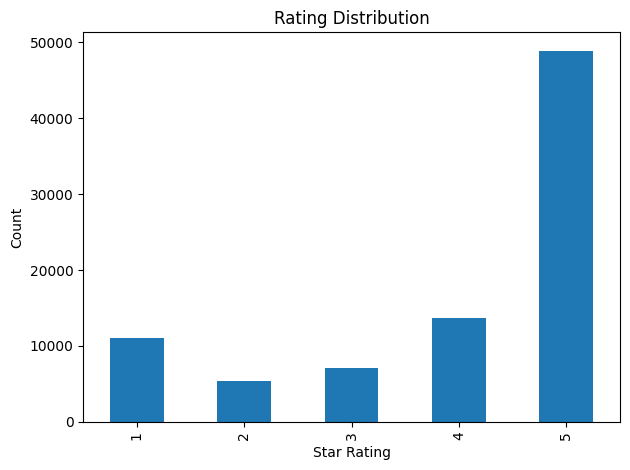

<Figure size 640x480 with 0 Axes>

In [10]:
if 'star_rating' in df.columns:
    print("\n Rating Distribution:")
    df['star_rating'].value_counts().sort_index()

    df['star_rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
    plt.xlabel('Star Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()  
    plt.clf()

# Calculate and plot string length (characters)

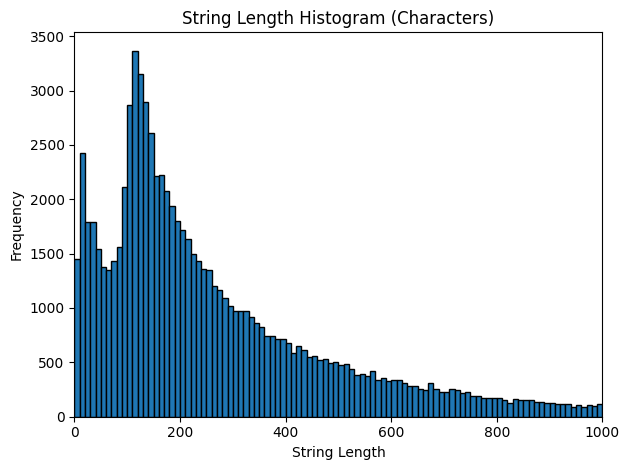

<Figure size 640x480 with 0 Axes>

In [11]:
df['String_Length'] = df['review_body'].astype(str).apply(len)

plt.hist(df['String_Length'], 
         bins=range(0, 1001, 10),  # bin every 10 chars up to 1000
         edgecolor='black')
plt.title('String Length Histogram (Characters)')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()
plt.clf()

# Calculate and plot word count

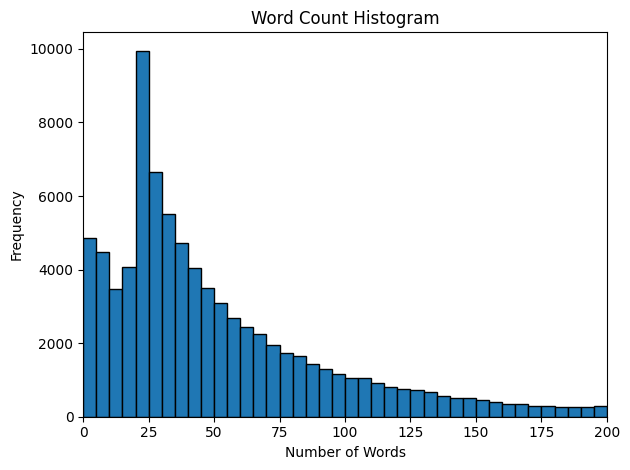

<Figure size 640x480 with 0 Axes>

In [12]:
df['Word_Count'] = df['review_body'].astype(str).apply(lambda x: len(x.split()))

plt.hist(df['Word_Count'], 
         bins=range(0, 201, 5),  # bin every 5 words up to 200
         edgecolor='black')
plt.title('Word Count Histogram')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()
plt.clf()

# 1. Data Preprocessing

# Drop rows with missing values


In [13]:
# Drop unnecessary columns
df = df[['star_rating', 'product_title', 'review_headline', 'review_body']]

# Drop rows with missing values
df.dropna(inplace=True)

# Convert star ratings to sentiment classes (0: Negative, 1: Positive)


In [14]:
# Convert star ratings to binary sentiment (0: Negative, 1: Positive)
df['sentiment'] = df['star_rating'].apply(lambda x: 0 if x <= 3 else 1)

# Combine 3 columns

In [15]:
# Combine product title, review headline, and review body
df['combined_text'] = df['product_title'] + " " + df['review_headline'] + " " + df['review_body']

# Print class distribution


In [16]:
# Label mapping
label_names = {0: "Negative", 1: "Positive"}

# Count occurrences in the full dataset
class_counts = np.bincount(df['sentiment'])
total_samples = len(df)

print("Class Distribution (Full Dataset):")
for label, count in enumerate(class_counts):
    percentage = count / total_samples * 100
    print(f"{label_names[label]}: {count} samples ({percentage:.2f}%)")

Class Distribution (Full Dataset):
Negative: 23415 samples (27.25%)
Positive: 62504 samples (72.75%)


# View cleaned data

In [17]:
print("Sample of Cleaned Reviews with Labels:")
df[['star_rating', 'sentiment', 'combined_text']].sample(10, random_state=42)

Sample of Cleaned Reviews with Labels:


,star_rating,sentiment,combined_text
226,5,1,Viva Naturals #1 Best Selling Certified Organi...
71481,3,0,Clean + Easy Deluxe Home Electrolysis If you h...
72642,5,1,The Acuvibe Wireless Massager Amazing! I first...
11687,1,0,Personal Pedi Water Proof Electronic Hand and ...
71552,5,1,Denman Denman Styling Brush Heavy Weight 9 Row...
37974,5,1,Vktech Replacement Electric Toothbrush Heads P...
58155,4,1,"Lock Laces, Black Good For Those With Little T..."
39741,5,1,Oral-B Power Tip Replacement Electric Toothbru...
28511,2,0,Mega Motion Infinate Position Power Easy Comfo...
48480,5,1,"IQAir Pre-Filter Replacement for HealthPro, He..."


# 2. Tokenization and vocabulary


In [18]:
# Initialize RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# ANTI-OVERFITTING: Reduce max sequence length
MAX_LEN = 96  # Reduced from 128

# Function to tokenize a text dataset
def tokenize_data(texts, tokenizer, max_len):
    input_ids = []
    attention_masks = []
    
    for text in tqdm(texts):
        encoded_dict = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])
    
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

# Free up memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Tokenize the combined text
print("Tokenizing data...")
input_ids, attention_masks = tokenize_data(df['combined_text'].values, tokenizer, MAX_LEN)
labels = torch.tensor(df['sentiment'].values)

# Create a balanced dataset through sampling weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['sentiment'].values),
    y=df['sentiment'].values
)

print("Class weights:", class_weights)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizing data...


100%|██████████| 85919/85919 [00:50<00:00, 1695.66it/s]


Class weights: [1.83469998 0.68730801]


# 3. Split data: 80% train, 10% val, 10% test


In [19]:
# Create TensorDataset
dataset = TensorDataset(input_ids, attention_masks, labels)

# Split ratio 8:1:1
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

# Create random splits with fixed seeds for reproducibility
generator = torch.Generator().manual_seed(42)
train_dataset, temp_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size + test_size], generator=generator
)
val_dataset, test_dataset = torch.utils.data.random_split(
    temp_dataset, [val_size, test_size], generator=generator
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

Training dataset size: 68735
Validation dataset size: 8591
Testing dataset size: 8593


# 4. Model & Custom Trainer


In [20]:
# Extract labels for the training set to create weights
train_labels = []
for i in range(len(train_dataset)):
    _, _, label = train_dataset[i]
    train_labels.append(label.item())

# Compute weights for balancing classes during training
samples_weight = torch.tensor([class_weights[label] for label in train_labels])
weighted_sampler = WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(train_dataset),
    replacement=True
)

# ANTI-OVERFITTING: Smaller batch size for more noisy gradients
batch_size = 16  # Reduced from 64

# Create DataLoaders
train_dataloader = DataLoader(
    train_dataset,
    sampler=weighted_sampler,
    batch_size=batch_size
)

validation_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)

test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=batch_size
)

# 5. Roberta model


In [21]:
# FIXED: Custom RoBERTa model with additional regularization
class RobertaWithDropout(nn.Module):
    def __init__(self, model_name='roberta-base', num_labels=2, dropout_rate=0.5):
        super(RobertaWithDropout, self).__init__()
        self.roberta = RobertaForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
            output_attentions=False,
            output_hidden_states=False,
        )
        
        # Add extra dropout layer
        self.dropout = nn.Dropout(dropout_rate)
        
        # Create custom classifier to work with mean pooled features
        self.custom_classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.roberta.config.hidden_size, self.roberta.config.hidden_size),
            nn.Tanh(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.roberta.config.hidden_size, num_labels)
        )
        
        # Freeze some layers to prevent overfitting
        self.freeze_layers(num_layers_to_freeze=6)  # Freeze bottom 6 layers
        
    def freeze_layers(self, num_layers_to_freeze):
        # Freeze embeddings
        for param in self.roberta.roberta.embeddings.parameters():
            param.requires_grad = False
            
        # Freeze bottom transformer layers
        for i in range(num_layers_to_freeze):
            for param in self.roberta.roberta.encoder.layer[i].parameters():
                param.requires_grad = False
        
        print(f"Frozen {num_layers_to_freeze} transformer layers and embeddings")
    
    def forward(self, input_ids, attention_mask, labels=None):
        # Get the base RoBERTa outputs first
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        
        # Get the hidden states for mean pooling
        base_outputs = self.roberta.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = base_outputs.last_hidden_state
        
        # Mean pooling across sequence length (excluding padding)
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask
        
        # Apply custom classifier to pooled output
        custom_logits = self.custom_classifier(pooled_output)
        
        # Combine original logits with custom logits for regularization
        combined_logits = (outputs.logits + custom_logits) / 2.0
        
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(combined_logits.view(-1, 2), labels.view(-1))
        
        return type('obj', (object,), {'loss': loss, 'logits': combined_logits})()

# Load model with additional regularization
model = RobertaWithDropout(dropout_rate=0.5)

# ANTI-OVERFITTING: Increase base model dropout
model.roberta.config.hidden_dropout_prob = 0.3
model.roberta.config.attention_probs_dropout_prob = 0.3

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.to(device)

# ANTI-OVERFITTING: Much lower learning rate and higher weight decay
optimizer = AdamW(model.parameters(), 
                lr=5e-6,      # Much lower learning rate
                eps=1e-8,
                weight_decay=0.2  # Higher weight decay
                )

# ANTI-OVERFITTING: Fewer epochs with aggressive early stopping
epochs = 5  # Reduced from 8

# Get total steps for scheduler
total_steps = len(train_dataloader) * epochs

# Create learning rate scheduler with warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=int(0.1*total_steps),  # Reduced warmup
    num_training_steps=total_steps
)

# ANTI-OVERFITTING: Aggressive early stopping
best_val_f1 = 0.0
patience = 2  # Very low patience
early_stop_counter = 0

# Function to format time
import time
import datetime
def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round(elapsed))))

# Store training and validation statistics
training_stats = []

# Store losses and accuracies for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Store batch-level metrics for detailed plotting
batch_train_losses = []
batch_train_accuracies = []
batch_numbers = []
batch_counter = 0

# ANTI-OVERFITTING: No gradient accumulation (more frequent updates with noise)
gradient_accumulation_steps = 1


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Frozen 6 transformer layers and embeddings
Using device: cuda


# 6. Train and evaluate


In [22]:
# Training loop
print("Beginning training with anti-overfitting measures...")
total_training_time = 0

for epoch in range(epochs):
    print(f'\n======== Epoch {epoch + 1} / {epochs} ========')
    
    # Training
    print('Training...')
    start_time = time.time()
    
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0
    
    for step, batch in enumerate(tqdm(train_dataloader)):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        
        # Forward pass
        outputs = model(
            b_input_ids, 
            attention_mask=b_input_mask, 
            labels=b_labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Accumulate loss
        total_train_loss += loss.item()
        
        # Calculate training accuracy
        preds = torch.argmax(logits, dim=1).flatten()
        accuracy = (preds == b_labels).cpu().numpy().mean()
        total_train_accuracy += accuracy
        
        # Store batch-level metrics (every 25 batches for plotting)
        if batch_counter % 25 == 0:
            batch_train_losses.append(loss.item())
            batch_train_accuracies.append(accuracy)
            batch_numbers.append(batch_counter // 25)
        
        batch_counter += 1
        
        # Backward pass
        loss.backward()
        
        # ANTI-OVERFITTING: Stronger gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)  # Reduced from 1.0
        
        # Update parameters
        optimizer.step()
        scheduler.step()
        
        # Clear gradients
        model.zero_grad()
    
    # Training metrics
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_accuracy = total_train_accuracy / len(train_dataloader)
    
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)
    
    # Measure training time
    training_time = time.time() - start_time
    total_training_time += training_time
    
    print(f"Average training loss: {avg_train_loss:.4f}")
    print(f"Average training accuracy: {avg_train_accuracy:.4f}")
    print(f"Training epoch took: {format_time(training_time)}")
    
    # Validation
    print("\nRunning Validation...")
    
    model.eval()
    total_eval_loss = 0
    total_eval_accuracy = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(validation_dataloader):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        
        with torch.no_grad():
            outputs = model(
                b_input_ids, 
                attention_mask=b_input_mask, 
                labels=b_labels
            )
        
        loss = outputs.loss
        logits = outputs.logits
        
        total_eval_loss += loss.item()
        
        # Calculate validation accuracy
        preds = torch.argmax(logits, dim=1).flatten()
        accuracy = (preds == b_labels).cpu().numpy().mean()
        total_eval_accuracy += accuracy
        
        # Store predictions and labels for metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())
    
    # Validation metrics
    avg_val_loss = total_eval_loss / len(validation_dataloader)
    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_accuracy)
    
    print(f"Validation Loss: {avg_val_loss:.4f}")
    print(f"Validation Accuracy: {avg_val_accuracy:.4f}")
    
    # Calculate validation metrics
    val_precision = precision_score(all_labels, all_preds, average='weighted')
    val_recall = recall_score(all_labels, all_preds, average='weighted')
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall: {val_recall:.4f}")
    print(f"Validation F1: {val_f1:.4f}")
    
    # ANTI-OVERFITTING: Monitor overfitting gap
    train_val_gap = avg_train_accuracy - avg_val_accuracy
    print(f"Training-Validation Gap: {train_val_gap:.4f}")
    if train_val_gap > 0.05:  # If gap > 5%, warn about overfitting
        print("⚠️  Warning: Potential overfitting detected!")
    
    # Store stats for this epoch
    training_stats.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'train_accuracy': avg_train_accuracy,
        'val_accuracy': avg_val_accuracy,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'training_time': training_time,
        'train_val_gap': train_val_gap
    })
    
    # ANTI-OVERFITTING: Early stopping based on validation F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        early_stop_counter = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_roberta_anti_overfitting.pt')
        print("✅ Best model saved!")
    else:
        early_stop_counter += 1
        print(f"❌ Validation F1 did not improve. Early stopping counter: {early_stop_counter}/{patience}")
        
    if early_stop_counter >= patience:
        print("🛑 Early stopping triggered!")
        break

print(f"\nTotal training time: {format_time(total_training_time)}")

# Create epoch-wise training summary table
training_df = pd.DataFrame(training_stats)
print("\nAnti-Overfitting Training Summary:")
print("="*100)
print(f"{'Epoch':<6} {'Train Loss':<12} {'Val Loss':<10} {'Train Acc':<10} {'Val Acc':<10} {'F1':<8} {'Gap':<8} {'Status':<15}")
print("="*100)
for _, row in training_df.iterrows():
    status = "✅ Good" if row['train_val_gap'] <= 0.05 else "⚠️  Overfitting"
    print(f"{row['epoch']:<6} {row['train_loss']:<12.6f} {row['val_loss']:<10.6f} {row['train_accuracy']:<10.6f} {row['val_accuracy']:<10.6f} {row['val_f1']:<8.6f} {row['train_val_gap']:<8.6f} {status:<15}")
print("="*100)

Beginning training with anti-overfitting measures...

======== Epoch 1 / 5 ========
Training...


100%|██████████| 4296/4296 [23:48<00:00,  3.01it/s]


Average training loss: 0.2985
Average training accuracy: 0.8585
Training epoch took: 0:23:48

Running Validation...


100%|██████████| 537/537 [01:26<00:00,  6.21it/s]


Validation Loss: 0.1832
Validation Accuracy: 0.9424
Validation Precision: 0.9420
Validation Recall: 0.9424
Validation F1: 0.9421
Training-Validation Gap: -0.0839
✅ Best model saved!

======== Epoch 2 / 5 ========
Training...


...

Validation Loss: 0.1920
Validation Accuracy: 0.9414
Validation Precision: 0.9424
Validation Recall: 0.9415
Validation F1: 0.9418
Training-Validation Gap: 0.0007
❌ Validation F1 did not improve. Early stopping counter: 1/2

======== Epoch 3 / 5 ========
Training...


100%|██████████| 4296/4296 [23:56<00:00,  2.99it/s]


Average training loss: 0.1695
Average training accuracy: 0.9507
Training epoch took: 0:23:56

Running Validation...


100%|██████████| 537/537 [01:26<00:00,  6.21it/s]

Validation Loss: 0.2455
Validation Accuracy: 0.9375
Validation Precision: 0.9409
Validation Recall: 0.9375
Validation F1: 0.9384
Training-Validation Gap: 0.0132
❌ Validation F1 did not improve. Early stopping counter: 2/2
🛑 Early stopping triggered!

Total training time: 1:11:40

Anti-Overfitting Training Summary:
Epoch  Train Loss   Val Loss   Train Acc  Val Acc    F1       Gap      Status         
1.0    0.298526     0.183228   0.858488   0.942388   0.942066 -0.083901 ✅ Good         
2.0    0.179409     0.192021   0.942198   0.941449   0.941802 0.000749 ✅ Good         
3.0    0.169528     0.245493   0.950651   0.937492   0.938378 0.013159 ✅ Good         


# 8. Plot metrics

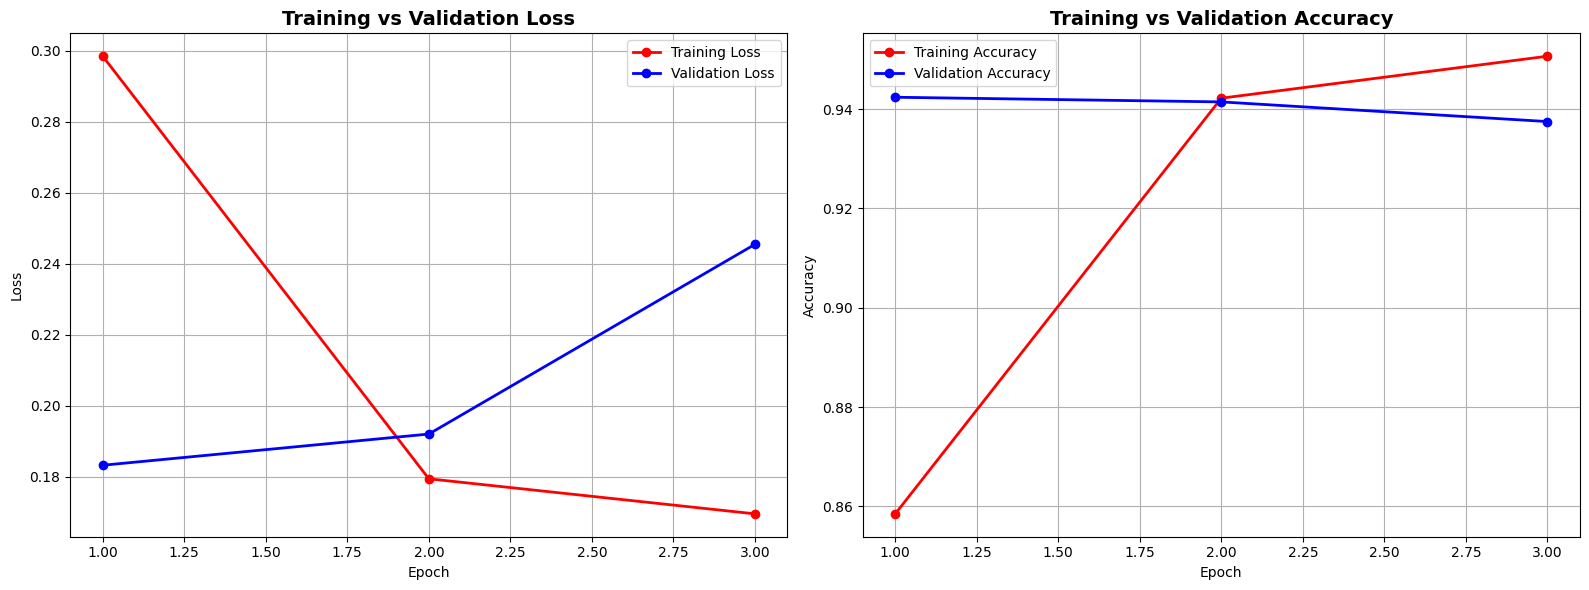

In [23]:
# PLOTTING: Epoch-based training vs validation loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Epochs starting from 1
epochs_range = list(range(1, len(train_losses) + 1))

# Plot 1: Training and Validation Loss
ax1.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o', linewidth=2)
ax1.plot(epochs_range, val_losses, label='Validation Loss', color='blue', marker='o', linewidth=2)
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot 2: Training and Validation Accuracy
ax2.plot(epochs_range, train_accuracies, label='Training Accuracy', color='red', marker='o', linewidth=2)
ax2.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='blue', marker='o', linewidth=2)
ax2.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_validation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


# 9. Final test evaluation and classification report


Evaluating model on test set...


100%|██████████| 538/538 [01:26<00:00,  6.22it/s]



🎯 FINAL TEST RESULTS (ANTI-OVERFITTING MODEL)
Test Accuracy:  0.9396
Test Precision: 0.9391
Test Recall:    0.9396
Test F1-Score:  0.9393

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.89      2311
    Positive       0.95      0.96      0.96      6282

    accuracy                           0.94      8593
   macro avg       0.93      0.92      0.92      8593
weighted avg       0.94      0.94      0.94      8593



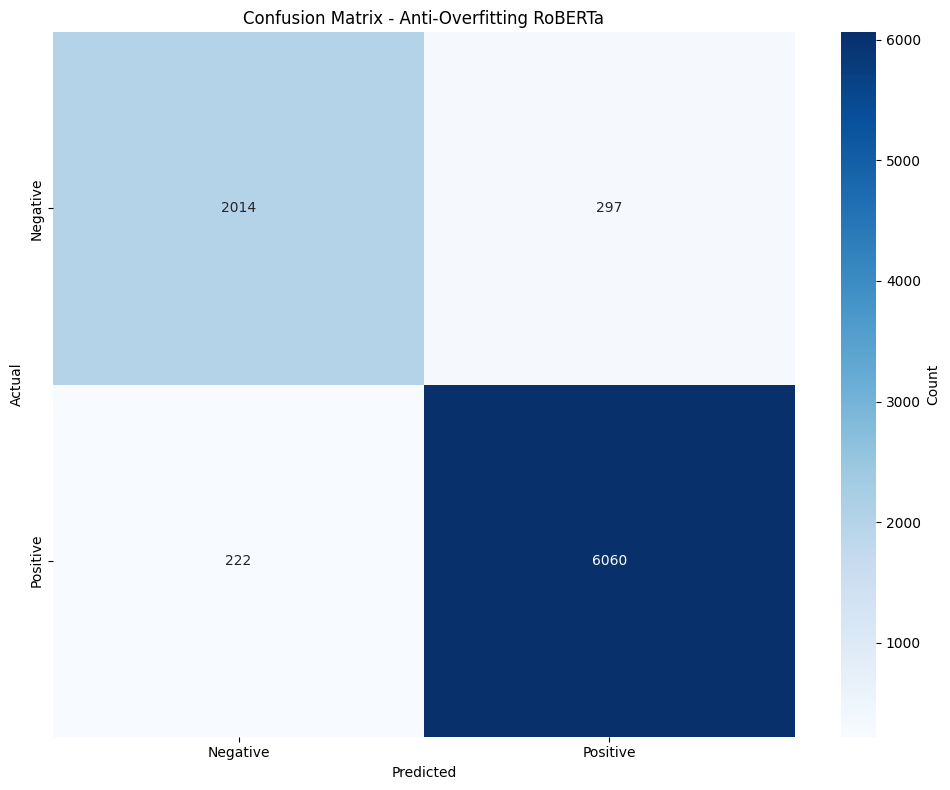


🔮 SAMPLE PREDICTIONS
Text: 'This product is amazing and works perfectly!'
Prediction: Positive (Confidence: 0.999)
----------------------------------------
Text: 'Terrible quality, broke after one day'
Prediction: Negative (Confidence: 0.999)
----------------------------------------
Text: 'It's okay, nothing special but does the job'
Prediction: Negative (Confidence: 0.985)
----------------------------------------

🛡️  ANTI-OVERFITTING CONFIGURATION SUMMARY
Key Changes Made to Prevent Overfitting:
• Dataset Size: Using full dataset
• Data Split: 80% train, 10% val, 10% test
• Max Length: Reduced to 96 tokens (from 128)
• Text Length: Limited to 128 words (from 256)
• Batch Size: Reduced to 16 (from 64) for noisy gradients
• Learning Rate: Much lower at 5e-6 (from 1e-5)
• Weight Decay: Increased to 0.2 (from 0.1)
• Epochs: Set to 5
• Layer Freezing: Bottom 6 layers + embeddings frozen
• Extra Dropout: 0.5 dropout rate added
• Early Stopping: Aggressive patience of 2 epochs
• Gradient C

In [24]:
# Load the best model for testing
model.load_state_dict(torch.load('best_roberta_anti_overfitting.pt'))

# Test the model
print("\nEvaluating model on test set...")
model.eval()
test_predictions = []
test_true_labels = []

for batch in tqdm(test_dataloader):
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)
    
    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_input_mask)
    
    logits = outputs.logits
    
    # Move predictions and labels to CPU
    predictions = torch.argmax(logits, dim=1).cpu().numpy()
    labels = b_labels.cpu().numpy()
    
    test_predictions.extend(predictions)
    test_true_labels.extend(labels)

# Calculate test metrics
test_accuracy = accuracy_score(test_true_labels, test_predictions)
test_precision = precision_score(test_true_labels, test_predictions, average='weighted')
test_recall = recall_score(test_true_labels, test_predictions, average='weighted')
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted')

print("\n" + "="*60)
print("🎯 FINAL TEST RESULTS (ANTI-OVERFITTING MODEL)")
print("="*60)
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print("="*60)

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_true_labels, test_predictions, target_names=['Negative', 'Positive']))

# Create and plot confusion matrix
cm = confusion_matrix(test_true_labels, test_predictions)
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Anti-Overfitting RoBERTa')

plt.tight_layout()
plt.savefig('confusion_matrix_anti_overfitting.png', dpi=300, bbox_inches='tight')
plt.show()

# Function to predict sentiment for new text
def predict_sentiment(text, model, tokenizer, device):
    encoded_dict = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    
    input_ids = encoded_dict['input_ids'].to(device)
    attention_mask = encoded_dict['attention_mask'].to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
    
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=1).item()
    confidence = torch.softmax(logits, dim=1).max().item()
    
    return "Positive" if prediction == 1 else "Negative", confidence

# Example usage
sample_texts = [
    "This product is amazing and works perfectly!",
    "Terrible quality, broke after one day",
    "It's okay, nothing special but does the job"
]

print("\n" + "="*60)
print("🔮 SAMPLE PREDICTIONS")
print("="*60)
for text in sample_texts:
    sentiment, confidence = predict_sentiment(text, model, tokenizer, device)
    print(f"Text: '{text}'")
    print(f"Prediction: {sentiment} (Confidence: {confidence:.3f})")
    print("-" * 40)

print("\n" + "="*80)
print("🛡️  ANTI-OVERFITTING CONFIGURATION SUMMARY")
print("="*80)
print("Key Changes Made to Prevent Overfitting:")
print("• Dataset Size: Using full dataset")
print("• Data Split: 80% train, 10% val, 10% test")
print("• Max Length: Reduced to 96 tokens (from 128)")
print("• Text Length: Limited to 128 words (from 256)")
print("• Batch Size: Reduced to 16 (from 64) for noisy gradients")
print("• Learning Rate: Much lower at 5e-6 (from 1e-5)")
print("• Weight Decay: Increased to 0.2 (from 0.1)")
print("• Epochs: Set to 5")
print("• Layer Freezing: Bottom 6 layers + embeddings frozen")
print("• Extra Dropout: 0.5 dropout rate added")
print("• Early Stopping: Aggressive patience of 2 epochs")
print("• Gradient Clipping: Stronger at 0.5 (from 1.0)")
print("• Overfitting Monitoring: 5% gap threshold with warnings")
print("• Fixed Architecture: Custom classifier for proper tensor handling")
print("="*80)

# Plot Test Accuracy by Class

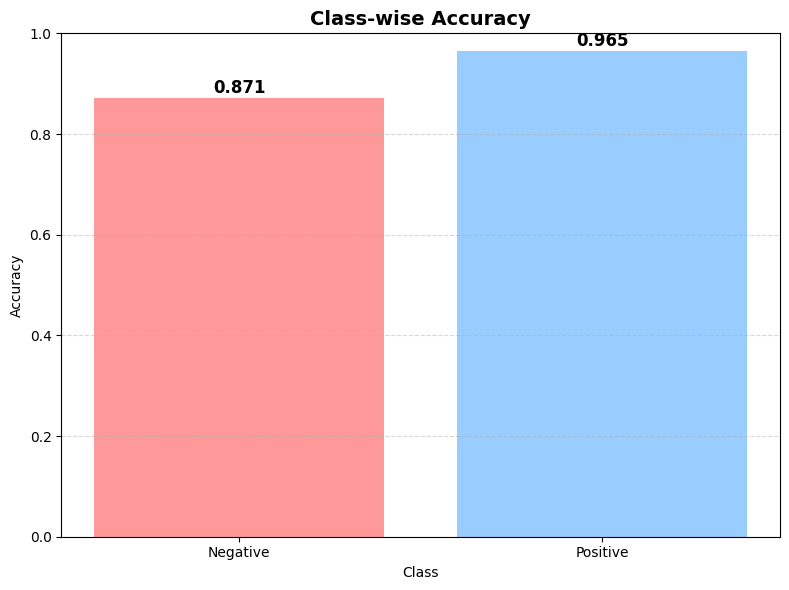

In [25]:
# CLASS-WISE ACCURACY PLOT (FOR BINARY SENTIMENT: 0 = Negative, 1 = Positive)
from collections import defaultdict

# Get list of unique labels
unique_labels = np.unique(test_true_labels)
class_names = ['Negative', 'Positive']

# Initialize counters
correct_counts = defaultdict(int)
total_counts = defaultdict(int)

# Count correct predictions per class
for true_label, pred_label in zip(test_true_labels, test_predictions):
    total_counts[true_label] += 1
    if true_label == pred_label:
        correct_counts[true_label] += 1

# Calculate accuracy per class
class_accuracies = {class_names[label]: correct_counts[label] / total_counts[label] 
                    for label in unique_labels}

# Plotting
plt.figure(figsize=(8, 6))
colors = ['#FF9999', '#99CCFF']
bars = plt.bar(class_accuracies.keys(), class_accuracies.values(), color=colors)

# Annotate bars with accuracy values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.3f}", ha='center', fontsize=12, fontweight='bold')

plt.ylim(0, 1)
plt.title("Class-wise Accuracy", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('class_wise_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
